# Лабораторная работа 2

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2_contingency, chi2
import statsmodels.api as sm

In [63]:
def plot_z_test(z, p_value):
    
    x = np.linspace(-3, 3, 100)
    y = norm.pdf(x, 0, 1)
    
    plt.plot(x, y, 'b-', linewidth=1.5, label='N(0,1)')
    plt.axvline(x=z, color='red', linewidth=1.5, label=f'z = {z:.2f}')
    plt.axvline(x=-z, color='red', linewidth=1.5)
    plt.axvline(x=1.96, color='gray', linewidth=1, linestyle=':', label='±1.96')
    plt.axvline(x=-1.96, color='gray', linewidth=1, linestyle=':')
    
    # Закрашиваем p-value
    x_fill = np.linspace(abs(z), 3, 50)
    plt.fill_between(x_fill, 0, norm.pdf(x_fill, 0, 1), alpha=0.3, color='red', label=f'p-value = {p_value:.3f}')
    x_fill_neg = np.linspace(-3, -abs(z), 50)
    plt.fill_between(x_fill_neg, 0, norm.pdf(x_fill_neg, 0, 1), alpha=0.3, color='red')
    
    # Настройка осей и заголовка
    plt.xlabel('z')
    plt.ylabel('')
    plt.title(f'Z-тест: z = {z:.2f}, p = {p_value:.3f}')
    plt.grid(True, alpha=0.2)
    
    # Правильный способ убрать spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Добавляем легенду
    plt.legend(loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.show()

In [64]:
def plot_chi2_test(chi2_stat, p_value):
    
    x = np.linspace(0, max(8, chi2_stat*1.2), 100)
    y = chi2.pdf(x, 1)
    
    plt.plot(x, y, 'g-', linewidth=1.5, label='χ²-распределение (df=1)')
    plt.axvline(x=chi2_stat, color='red', linewidth=1.5, label=f'χ² = {chi2_stat:.2f}')
    plt.axvline(x=3.84, color='gray', linewidth=1, linestyle=':', label='Крит. значение (3.84)')
    
    # Закрашиваем p-value
    x_fill = np.linspace(chi2_stat, max(8, chi2_stat*1.2), 50)
    plt.fill_between(x_fill, 0, chi2.pdf(x_fill, 1), alpha=0.3, color='red', label=f'p-value = {p_value:.3f}')
    
    plt.xlabel('χ²')
    plt.ylabel('Плотность')
    plt.title(f'Хи-квадрат тест')
    plt.grid(True, alpha=0.2)
    plt.legend(loc='upper right', fontsize=9)
    
    # Убираем лишние spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [65]:
def func_01(s1, n1, s2, n2):

	p1 = s1 / n1
	p2 = s2 / n2
	p = (s1 + s2) / (n1 + n2)

	z = (p2 - p1) / ((p * (1 - p) * (1 / n1 + 1 / n2)) ** 0.5)

	p_value = norm.cdf(-abs(z))

	print(f'z = {abs(z):.12f}, p_value = {p_value * 2:.12f}')
	plot_z_test(z, p_value)

In [66]:
def func_02(s1, n1, s2, n2):
    
	z, p_value = sm.stats.proportions_ztest([s1, s2], [n1, n2])

	print(f'z = {abs(z):.12f}, p_value = {p_value:.12f}')

In [67]:
def func_03(s1, n1, s2, n2):
    
	arr = np.array([[s1, n1-s1], [s2, n2-s2]])
	chi2, p_value, _, _ = chi2_contingency(arr, correction = False)

	print(f'chi = {abs(chi2 ** 0.5):.12f}, p_value = {p_value:.12f}')
	plot_chi2_test(chi2, p_value)

Сравним результаты Надаля в геймах, когда он подавал, и в геймах, когда он принимал
подачу.

Результаты Надаля на глиняных и других кортах — геймы, в которых он подавал.

|Surface|WIN|LOSS|TOTAL|
|-|-|-|-|
|Clay|1090|171|1261|
|Noclay|2747|446|3193|
|Total|3837|617|4554|

z = 0.354570750872, p_value = 0.722911191632


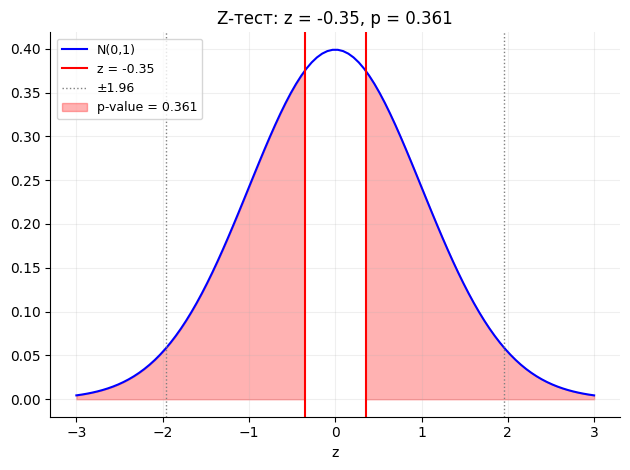

z = 0.354570750872, p_value = 0.722911191632
chi = 0.354570750872, p_value = 0.722911191632


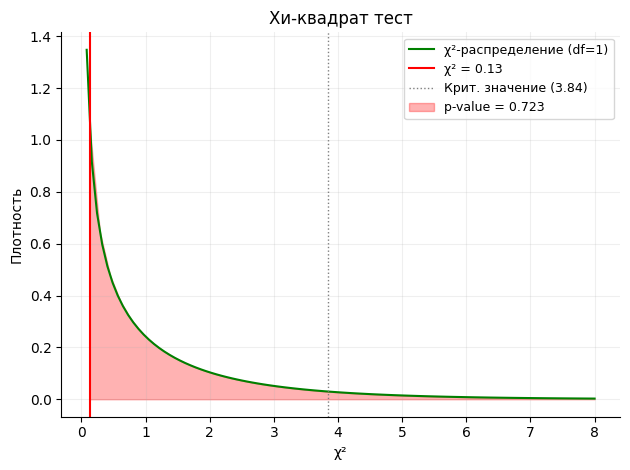

In [68]:
s1 = 1090
n1 = s1 + 171

s2 = 2747
n2 = s2 + 446

func_01(s1, n1, s2, n2)
func_02(s1, n1, s2, n2)
func_03(s1, n1, s2, n2)

Результаты Надаля на глиняных и других кортах — геймы, в которых он принимал подачу

|Surface|WIN|LOSS|TOTAL|
|-|-|-|-|
|Clay|570|692|1262|
|Noclay|911|2269|3180|
|Total|1482|2961|4442|

p_value > 0.05, результаты статистически незначимые. Мы не можем сказать, что тип корта влияет на процент выигрыша при подаче.

z = 10.531957990552, p_value = 0.000000000000


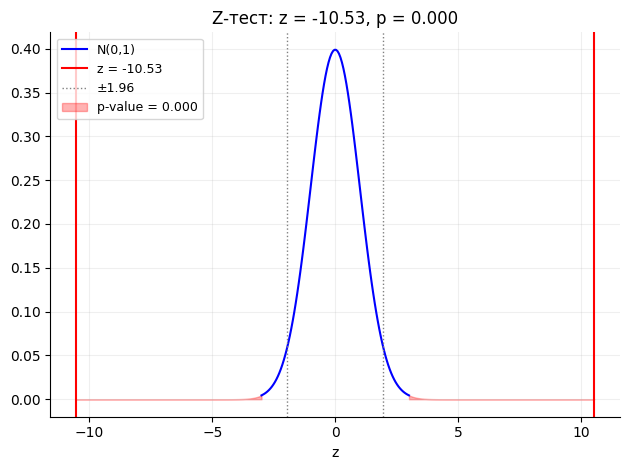

z = 10.531957990552, p_value = 0.000000000000
chi = 10.531957990552, p_value = 0.000000000000


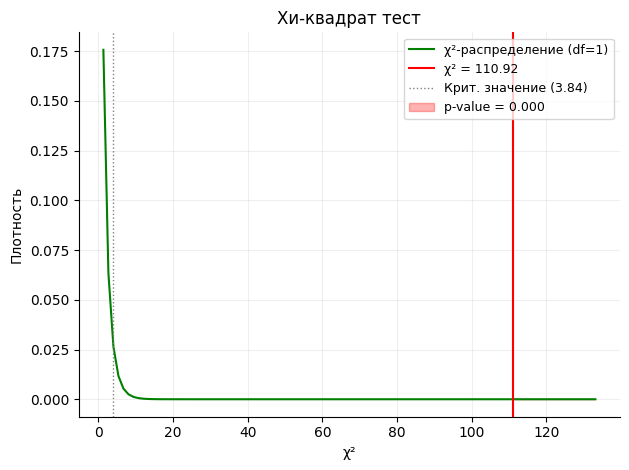

In [69]:
s1 = 570
n1 = s1 + 692

s2 = 911
n2 = s2 + 2269

func_01(s1, n1, s2, n2)
func_02(s1, n1, s2, n2)
func_03(s1, n1, s2, n2)

p_value < 0.05, результаты статистически значимые. Мы можем сказать, что тип корта влияет на процент выигрыша при приеме подачи.